In [1]:
import json
from sentence_transformers import SentenceTransformer, util
import numpy as np
import os
import matplotlib.pyplot as plt
import glob
import re
import pandas as pd
from matplotlib.patches import Patch

# Calculating semantic diversity

## Loading sBERT embeddings

In [3]:
sbert_model = SentenceTransformer("all-MiniLM-L6-v2") 

def load_embeddings(path):
    embeddings_dict = {
        'sentences': [],
        'embeddings': []
    }
    
    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            embeddings_dict['sentences'].append(data['sentence'])
            embeddings_dict['embeddings'].append(np.array(data['embedding']))
            
    # Convert list of embeddings to a numpy array
    embeddings_dict['embeddings'] = np.array(embeddings_dict['embeddings'])
    return embeddings_dict


sbert_embeddings = {
    "Human":{
        "dolly_train_1": load_embeddings("../../Data/analysis/sentence_embeddings/Human/dolly_train_1_human_embeddings.jsonl"),
        "dolly_train_2": load_embeddings("../../Data/analysis/sentence_embeddings/Human/dolly_train_2_human_embeddings.jsonl"),
        "dolly_train_3": load_embeddings("../../Data/analysis/sentence_embeddings/Human/dolly_train_3_human_embeddings.jsonl"),
        "dolly_train_4": load_embeddings("../../Data/analysis/sentence_embeddings/Human/dolly_train_4_human_embeddings.jsonl")
    },
    "Small":{
        "dolly_train_1_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_1_Llama_embeddings.jsonl"),
        "dolly_train_2_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_2_Llama_embeddings.jsonl"),
        "dolly_train_3_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_3_Llama_embeddings.jsonl"),
        "dolly_train_4_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_4_Llama_embeddings.jsonl"),
        "dolly_train_2_Gemma": load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_2_Gemma_embeddings.jsonl"),
        "dolly_train_3_Qwen":  load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_3_Qwen2_embeddings.jsonl"),
        "dolly_train_4_Falcon": load_embeddings("../../Data/analysis/sentence_embeddings/Small/dolly_train_4_Falcon3-10B-Instruct_embeddings.jsonl")
    },
    "Medium":{
        "dolly_train_1_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_1_Llama_embeddings.jsonl"),
        "dolly_train_2_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_2_Llama_embeddings.jsonl"),
        "dolly_train_3_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_3_Llama_embeddings.jsonl"),
        "dolly_train_4_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_4_Llama_embeddings.jsonl"),
        "dolly_train_2_Mistral": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_2_Mistral_embeddings.jsonl"),
        "dolly_train_3_Qwen": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_3_Qwen_embeddings.jsonl"),
        "dolly_train_4_Command": load_embeddings("../../Data/analysis/sentence_embeddings/Medium/dolly_train_4_Command_embeddings.jsonl")
    },
    "Large": {
        "dolly_train_1_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_1_Llama_embeddings.jsonl"),
        "dolly_train_2_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_2_Llama_embeddings.jsonl"),
        "dolly_train_3_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_3_Llama_embeddings.jsonl"),
        "dolly_train_4_Llama": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_4_Llama_embeddings.jsonl"),
        "dolly_train_2_Gemini": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_2_Gemini_embeddings.jsonl"),
        "dolly_train_3_GPT": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_3_GPT_embeddings.jsonl"),
        "dolly_train_4_Deepseek": load_embeddings("../../Data/analysis/sentence_embeddings/Large/dolly_train_4_Deepseek_embeddings.jsonl")
    }
}


## Calculating cosine distances, semantic diversity, and saving to files in Data/analysis/semantic_diversity

In [5]:
def calculate_semantic_diversity(embeddings):
    """Calculate semantic diversity from embeddings."""
    # Calculate cosine similarities
    similarities = util.pytorch_cos_sim(embeddings, embeddings).numpy()
    
    # Convert to cosine distances
    cosine_distances = 1 - similarities
    
    # Create mask to exclude self-comparisons
    mask = np.ones_like(cosine_distances, dtype=bool)
    np.fill_diagonal(mask, False)
    
    # Calculate semantic diversity (average pairwise cosine distance)
    div_sem = np.mean(cosine_distances[mask])
    
    return cosine_distances, div_sem


def process_embeddings_directory(input_dir, output_dir):
    """Process all embedding files in a directory and save results."""
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Process each .jsonl file in the input directory
    for filename in os.listdir(input_dir):
        if filename.endswith('.jsonl'):
            # Load embeddings from jsonl file
            embeddings_path = os.path.join(input_dir, filename)
            embeddings_data = []
            
            with open(embeddings_path, 'r') as f:
                for line in f:
                    item = json.loads(line)
                    embeddings_data.append(item['embedding'])
            
            # Convert to numpy array
            embeddings = np.array(embeddings_data)
            
            # Calculate distances and diversity
            cosine_distances, div_sem = calculate_semantic_diversity(embeddings)
            
            # Create output filenames
            base_name = os.path.splitext(filename)[0]
            distances_filename = f"cosine_distances_{base_name}.npy"
            diversity_filename = f"semantic_diversity_{base_name}.txt"
            
            # Save results
            np.save(os.path.join(output_dir, distances_filename), cosine_distances)
            with open(os.path.join(output_dir, diversity_filename), 'w') as f:
                f.write(f"Semantic Diversity: {div_sem}")
            
            print(f"Processed {filename}")
            print(f"Semantic Diversity: {div_sem}")

def main():
    # Define base directories
    base_input_dir = "../../Data/analysis/sentence_embeddings"
    base_output_dir = "../../Data/analysis/semantic_diversity"
    
    # Process each category
    categories = ['Large', 'Medium', 'Small', 'Human']
    
    for category in categories:
        input_dir = os.path.join(base_input_dir, category)
        output_dir = os.path.join(base_output_dir, category)
        
        print(f"\nProcessing {category} embeddings...")
        process_embeddings_directory(input_dir, output_dir)

if __name__ == "__main__":
    main()


Processing Large embeddings...
Processed dolly_train_3_GPT_embeddings.jsonl
Semantic Diversity: 0.9525180006511944
Processed dolly_train_4_Deepseek_embeddings.jsonl
Semantic Diversity: 0.9442393045563153
Processed dolly_train_3_Llama_embeddings.jsonl
Semantic Diversity: 0.9544169748656655
Processed dolly_train_4_Llama_embeddings.jsonl
Semantic Diversity: 0.9522834085016512
Processed dolly_train_2_Gemini_embeddings.jsonl
Semantic Diversity: 0.9344836659768693
Processed dolly_train_2_Llama_embeddings.jsonl
Semantic Diversity: 0.9537142322017007
Processed dolly_train_1_Llama_embeddings.jsonl
Semantic Diversity: 0.9532744291928373

Processing Medium embeddings...
Processed dolly_train_2_Mistral_embeddings.jsonl
Semantic Diversity: 0.9473550580311478
Processed dolly_train_4_Command_embeddings.jsonl
Semantic Diversity: 0.9594719819377518
Processed dolly_train_3_Llama_embeddings.jsonl
Semantic Diversity: 0.953778444343985
Processed dolly_train_4_Llama_embeddings.jsonl
Semantic Diversity: 0.9

## Calculating std err

In [ ]:
# Calculating standard error

def calculate_standard_error(cosine_distances):
    """Calculate standard error from cosine distances."""
    # Create mask to exclude self-comparisons
    mask = np.ones_like(cosine_distances, dtype=bool)
    np.fill_diagonal(mask, False)

    std_dev = np.std(cosine_distances[mask], ddof=1)
    n = len(cosine_distances[mask])
    std_error = std_dev / np.sqrt(n)
    
    return std_error


cosine_distances = np.load("../../Data/analysis/semantic_diversity/Small/cosine_distances_dolly_train_2_Llama_embeddings.npy")
calculate_standard_error(cosine_distances)
    

np.float64(1.2353146093685257e-05)

### Standard error for individual datasets

In [ ]:
semantic_diversity_scores = pd.read_csv("../../Data/analysis/semantic_diversity/semantic_diversity_all.csv")

# Add a standard error column to the semantic_diversity_scores dataframe
semantic_diversity_scores['standard_error'] = None

# Define the base directory for the cosine distance files
base_dir = "../../Data/analysis/semantic_diversity"

# Iterate through each row in the dataframe
for idx, row in semantic_diversity_scores.iterrows():
    # Construct the path to the corresponding cosine distances file
    category = row['size']
    dataset = row['dataset']
    model = row['model']
    
    # Handle the "Human" case differently as it doesn't have a model name in the filename
    if category == "Human":
        file_name = f"cosine_distances_{dataset}_human_embeddings.npy"
    else:
        file_name = f"cosine_distances_{dataset}_{model}_embeddings.npy"
    
    file_path = os.path.join(base_dir, category, file_name)
    
    # Check if the file exists
    if os.path.exists(file_path):
        try:
            # Load the cosine distances and calculate the standard error
            cosine_distances = np.load(file_path)
            std_error = calculate_standard_error(cosine_distances)
            
            # Update the dataframe with the calculated standard error
            semantic_diversity_scores.at[idx, 'standard_error'] = std_error
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    else:
        print(f"Warning: File not found: {file_path}")

# Display the updated dataframe with standard errors
# semantic_diversity_scores.to_csv("../../Data/analysis/semantic_diversity/div_sem_std_err_all.csv", index=False)
# semantic_diversity_scores.head(25)

### Averaging semantic diversity scores and standard error over datasets

In [ ]:
semantic_diversity_scores = pd.read_csv("../../Data/analysis/semantic_diversity/div_sem_std_err_all.csv")

# Define the base directory for the cosine distance files
base_dir = "../../Data/analysis/semantic_diversity"

# Initialize a dictionary to store cosine distances for each category
cosine_distances_by_category = {
    "Human": [],
    "Small": [],
    "Medium": [],
    "Large": []
}

# Initialize dictionaries to store Llama-specific cosine distances for each category
llama_cosine_distances_by_category = {
    "Small": [],
    "Medium": [],
    "Large": []
}

# Iterate through each row in the dataframe
for idx, row in semantic_diversity_scores.iterrows():
    # Construct the path to the corresponding cosine distances file
    category = row['size']
    dataset = row['dataset']
    model = row['model']

    
    
    # Handle the "Human" case differently as it doesn't have a model name in the filename
    if category == "Human":
        file_name = f"cosine_distances_{dataset}_human_embeddings.npy"
    else:
        file_name = f"cosine_distances_{dataset}_{model}_embeddings.npy"
    
    file_path = os.path.join(base_dir, category, file_name)
    
    # Check if the file exists
    if os.path.exists(file_path):
        try:
            # Load the cosine distances 
            cosine_distances = np.load(file_path)
            cosine_distances_by_category[category].append(cosine_distances)
            
            # If this is a Llama model, also add to the Llama-specific dictionary
            if model == "Llama" and category in ["Small", "Medium", "Large"]:
                llama_cosine_distances_by_category[category].append(cosine_distances)
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    else:
        print(f"Warning: File not found: {file_path}")

# Function to calculate mean semantic diversity and standard error
def calculate_mean_and_standard_error(distances):
    all_distances = np.concatenate(distances)
    mean_diversity = np.mean(all_distances)
    standard_error = np.std(all_distances) / np.sqrt(len(all_distances))
    return mean_diversity, standard_error

# Calculate the mean semantic diversity and standard error for each category and add to dataframe
for category, distances in cosine_distances_by_category.items():
    if distances:
        mean_diversity, standard_error = calculate_mean_and_standard_error(distances)
        print(f"Category: {category}")
        print(f"Mean Semantic Diversity: {mean_diversity}")
        print(f"Standard Error: {standard_error}\n")
        
        # Add a new row to the dataframe for the category average
        new_row = {
            'dataset': 'all',
            'size': category,
            'model': 'average',
            'semantic diversity': mean_diversity,
            'standard_error': standard_error
        }
        semantic_diversity_scores = pd.concat([semantic_diversity_scores, pd.DataFrame([new_row])], ignore_index=True)
    else:
        print(f"No data available for category: {category}\n")

# Calculate the mean semantic diversity and standard error for Llama models in each category
for category, distances in llama_cosine_distances_by_category.items():
    if distances:
        mean_diversity, standard_error = calculate_mean_and_standard_error(distances)
        print(f"Llama Category: {category}")
        print(f"Mean Semantic Diversity: {mean_diversity}")
        print(f"Standard Error: {standard_error}\n")
        
        # Add a new row to the dataframe for the Llama category average
        new_row = {
            'dataset': 'all',
            'size': category,
            'model': 'Llama-average',
            'semantic diversity': mean_diversity,
            'standard_error': standard_error
        }
        semantic_diversity_scores = pd.concat([semantic_diversity_scores, pd.DataFrame([new_row])], ignore_index=True)
    else:
        print(f"No Llama data available for category: {category}\n")

# Display the updated dataframe with standard errors
# semantic_diversity_scores.to_csv("../../Data/analysis/semantic_diversity/div_sem_std_err_all_with_averages.csv", index=False)
# semantic_diversity_scores.head(30)

Category: Human
Mean Semantic Diversity: 0.9713236411918892
Standard Error: 0.0004951122201080557

Category: Small
Mean Semantic Diversity: 0.9530918310985492
Standard Error: 0.0004009700126210357

Category: Medium
Mean Semantic Diversity: 0.9530033149306856
Standard Error: 0.0004010153402187962

Category: Large
Mean Semantic Diversity: 0.9491401057470942
Standard Error: 0.00040554598145874055

Llama Category: Small
Mean Semantic Diversity: 0.95671175550155
Standard Error: 0.0005225325006774018

Llama Category: Medium
Mean Semantic Diversity: 0.953336282199838
Standard Error: 0.0005291702268115578

Llama Category: Large
Mean Semantic Diversity: 0.9532860580102948
Standard Error: 0.0005290656437729785



,dataset,size,model,semantic diversity,standard_error
0,dolly_train_1,Human,Human,0.971391,0.000012
1,dolly_train_2,Human,Human,0.971526,0.000012
2,dolly_train_3,Human,Human,0.971009,0.000012
3,dolly_train_4,Human,Human,0.971923,0.000012
4,dolly_train_1,Small,Llama,0.957518,0.000012
5,dolly_train_2,Small,Llama,0.957380,0.000012
6,dolly_train_3,Small,Llama,0.956723,0.000012
7,dolly_train_4,Small,Llama,0.955773,0.000012
8,dolly_train_2,Small,Gemma,0.934580,0.000013
9,dolly_train_3,Small,Qwen,0.948793,0.000013


# Plotting

## Plotting semantic diversity scores on bar charts

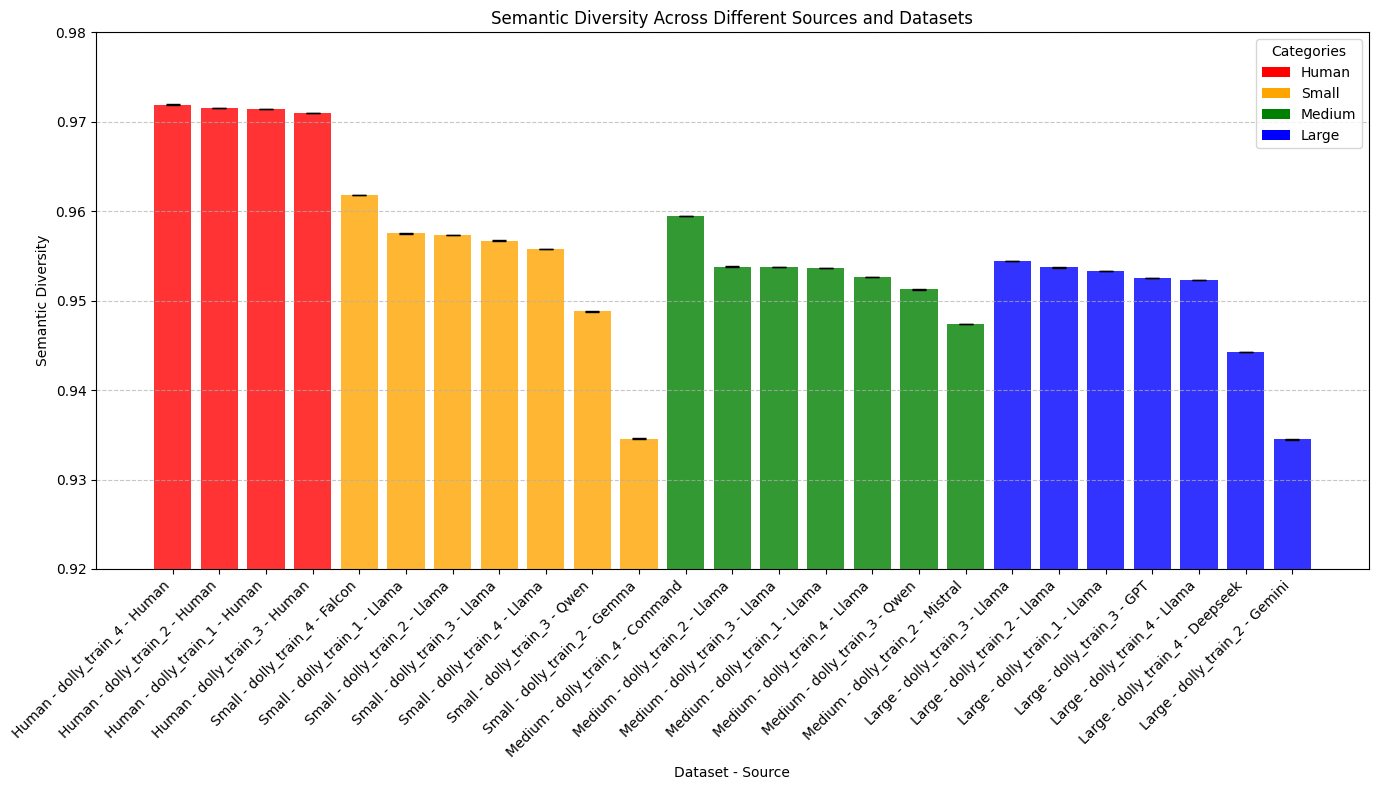

In [3]:
semantic_diversity_scores = pd.read_csv("../../Data/analysis/semantic_diversity/div_sem_std_err_all.csv")

def plot_semantic_diversity(semantic_diversity_scores):
    # Use the semantic_diversity_scores dataframe that's already loaded
    # Create a copy to avoid modifying the original
    df = semantic_diversity_scores.copy()
    
    # Create a new column for the category-dataset-model label
    df['label'] = df.apply(lambda row: f"{row['size']} - {row['dataset']} - {row['model']}", axis=1)
    
    # Define category order for sorting
    categories = ["Human", "Small", "Medium", "Large"]
    category_order = {cat: idx for idx, cat in enumerate(categories)}
    
    # Sort by category first, then by semantic diversity value (descending)
    df['category_order'] = df['size'].map(category_order)
    df = df.sort_values(by=['category_order', 'semantic diversity'], ascending=[True, False])
    
    # Prepare for plotting
    labels = df['label'].tolist()
    values = df['semantic diversity'].tolist()
    errors = df['standard_error'].tolist()
    
    # Create color mapping for categories
    category_colors = {
        'Human': 'red',
        'Small': 'orange',
        'Medium': 'green',
        'Large': 'blue'
    }
    
    # Assign colors based on category
    colors = [category_colors.get(label.split(' - ')[0], 'gray') for label in labels]
    
    # Create the plot
    plt.figure(figsize=(14, 8))
    bars = plt.bar(labels, values, color=colors, yerr=errors, capsize=5, ecolor='black', alpha=0.8)
    
    # Add labels and title
    plt.xlabel('Dataset - Source')
    plt.ylabel('Semantic Diversity')
    plt.title('Semantic Diversity Across Different Sources and Datasets')
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    
    # Add a grid for easier reading
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Set y-axis lower limit to 0.92, top to 0.98
    plt.ylim(bottom=0.92, top=0.98)
    
    # Adjust layout
    plt.tight_layout()
    
    # Add a legend
    
    legend_elements = [Patch(facecolor=color, label=cat) 
                      for cat, color in category_colors.items()]
    plt.legend(handles=legend_elements, title='Categories')
    
    # Show the plot
    plt.show()

# Run the plotting function
plot_semantic_diversity(semantic_diversity_scores)


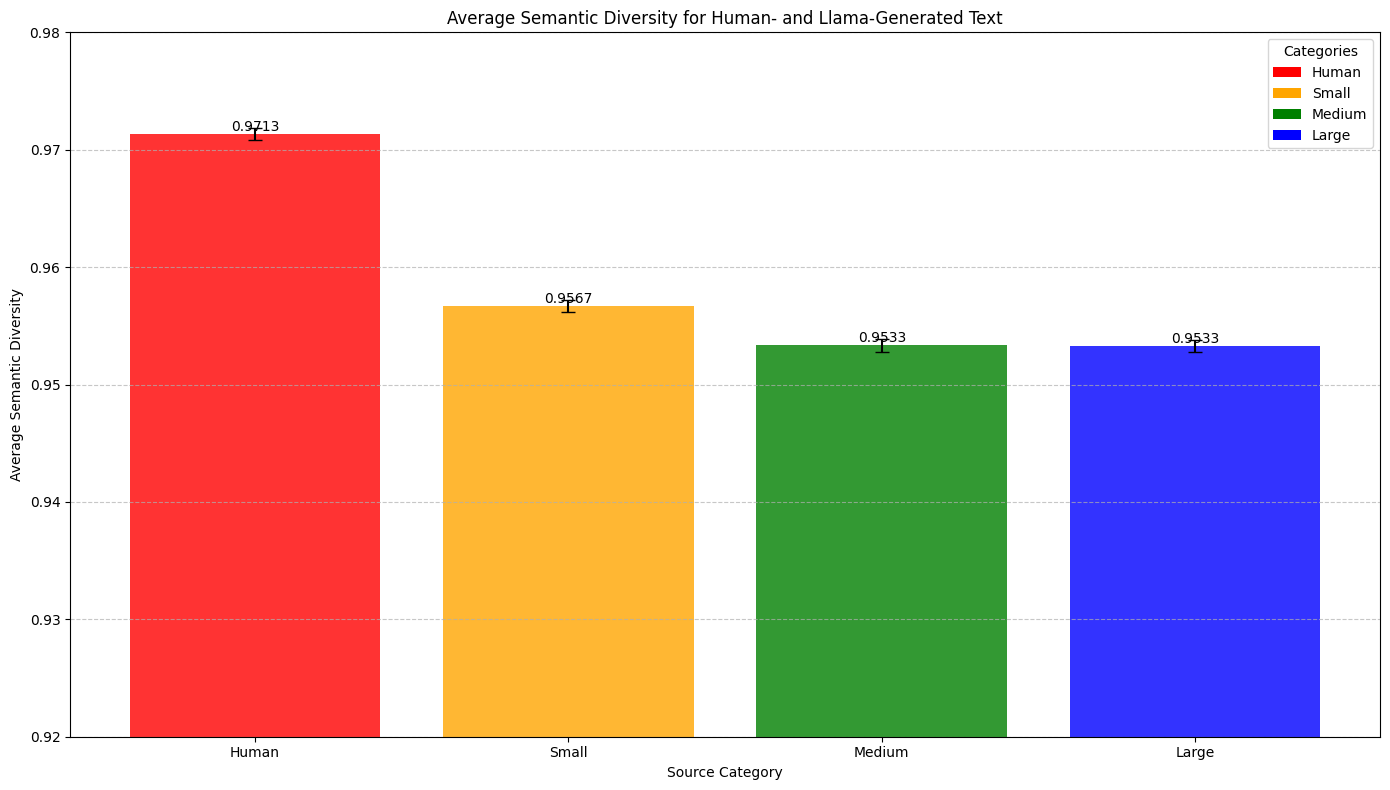

In [21]:
def plot_semantic_diversity(df):
    # Get the human average row
    human_avg_row = df[(df['model'] == 'average') & (df['size'] == 'Human')]
    # Filter for rows that contain 'Llama-average' in the model column
    llama_avg_df = df[df['model'] == 'Llama-average']
    # Concatenate with human row first, then Llama averages
    avg_df = pd.concat([human_avg_row, llama_avg_df])
    
    # Prepare for plotting
    labels = avg_df['size'].tolist()
    values = avg_df['semantic diversity'].tolist()
    errors = avg_df['standard_error'].tolist()
    
    # Create color mapping for categories
    category_colors = {
        'Human': 'red',
        'Small': 'orange',
        'Medium': 'green',
        'Large': 'blue'
    }
    
    # Assign colors based on category
    colors = [category_colors.get(label, 'gray') for label in labels]
    
    # Create the plot
    plt.figure(figsize=(14, 8))
    bars = plt.bar(labels, values, color=colors, yerr=errors, capsize=5, ecolor='black', alpha=0.8)
    
    # Add labels and title
    plt.xlabel('Source Category')
    plt.ylabel('Average Semantic Diversity')
    plt.title('Average Semantic Diversity for Human- and Llama-Generated Text')
    
    # Add a grid for easier reading
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Set y-axis limits
    plt.ylim(bottom=0.92, top=0.98)
    
    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', rotation=0)
    
    # Adjust layout
    plt.tight_layout()
    
    # Add a legend
    legend_elements = [Patch(facecolor=color, label=cat) 
                      for cat, color in category_colors.items()]
    plt.legend(handles=legend_elements, title='Categories')
    
    # Show the plot
    plt.show()

# Run the plotting function
semantic_diversity_scores = pd.read_csv("../../Data/analysis/semantic_diversity/div_sem_std_err_all_with_averages.csv")
plot_semantic_diversity(semantic_diversity_scores)


## Plotting cosine distances on individual histograms

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24


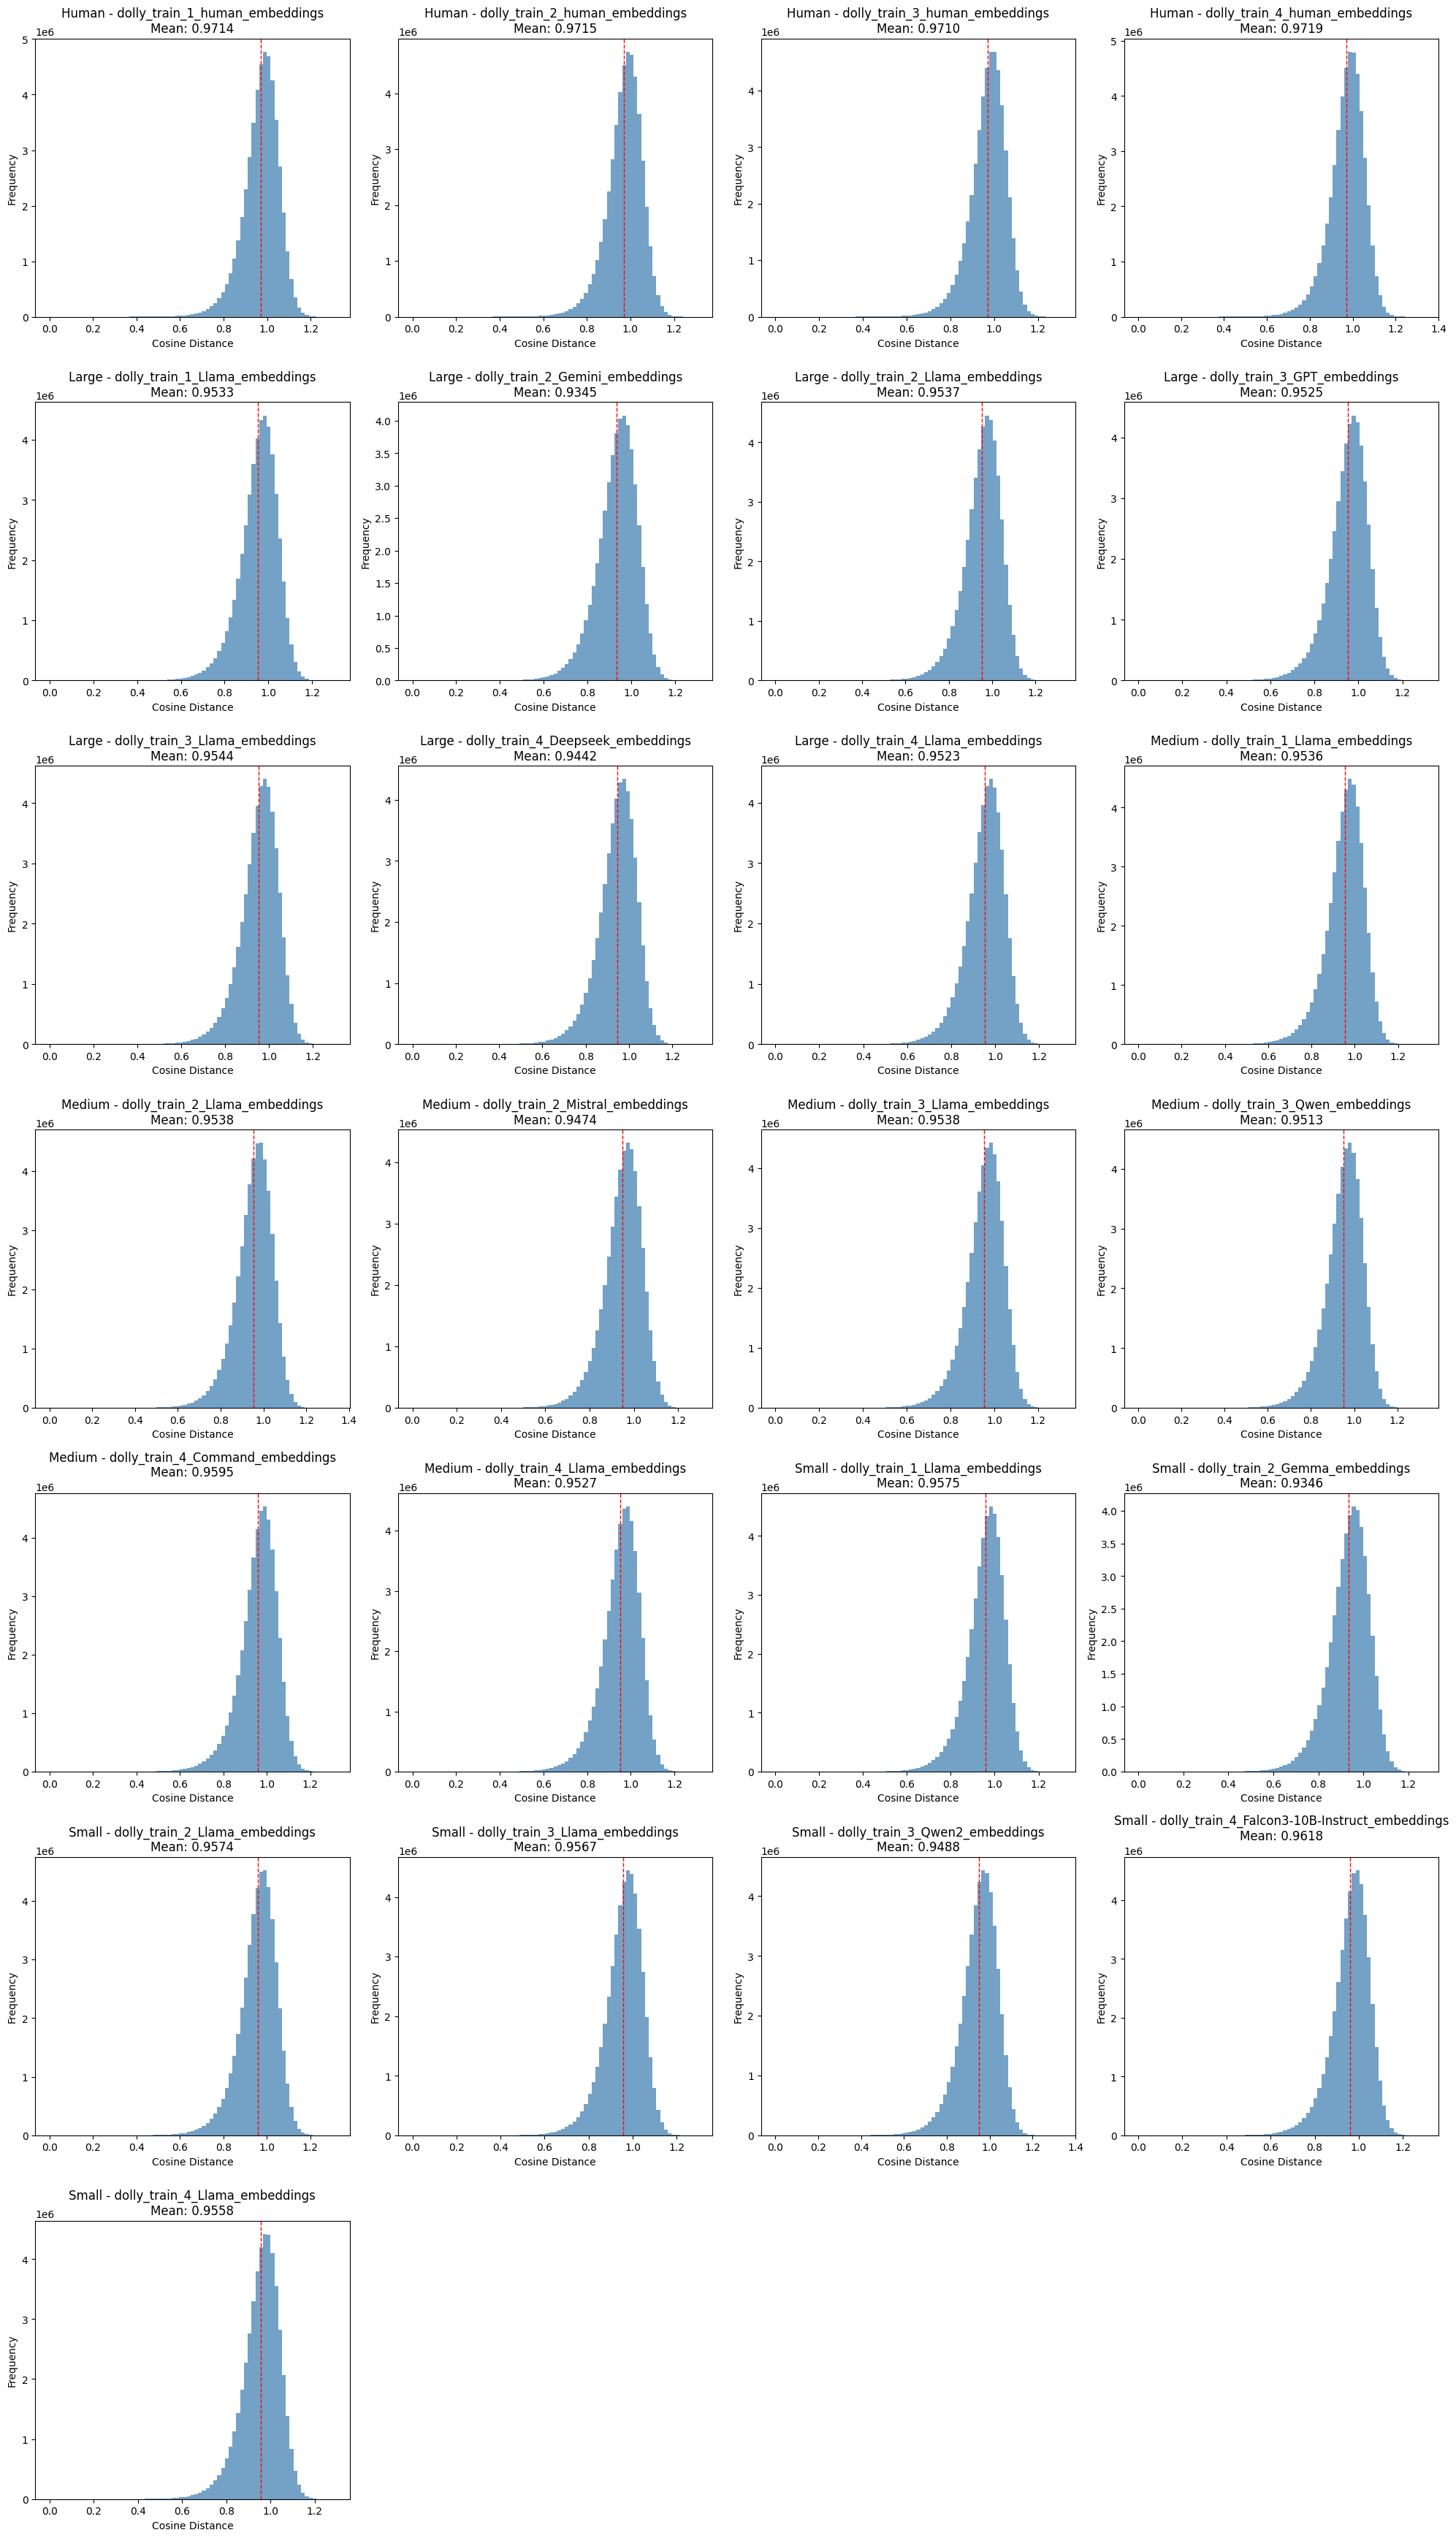

In [12]:
def plot_cosine_distance_histogram(ax, file_path, title=None):
    """
    Plot a histogram of cosine distances from a numpy file on a given axis.
    
    Args:
        ax: Matplotlib axis to plot on
        file_path: Path to the .npy file containing the cosine distance matrix
        title: Optional title for the plot
    """
    # Load the cosine distance matrix
    cosine_distances = np.load(file_path)
    
    # Flatten the matrix to get all pairwise distances
    # Exclude the diagonal (self-comparisons) which are always 0
    mask = ~np.eye(cosine_distances.shape[0], dtype=bool)
    distances = cosine_distances[mask]
    
    # Calculate mean
    mean_distance = np.mean(distances)
    
    # Create the histogram with more bins
    ax.hist(distances, bins=75, alpha=0.75, color='steelblue')
    
    # Add a vertical line for the mean
    ax.axvline(mean_distance, color='red', linestyle='dashed', linewidth=1)
    
    # Add labels
    ax.set_xlabel('Cosine Distance')
    ax.set_ylabel('Frequency')
    
    # Set title if provided, otherwise use the filename
    if title is None:
        title = os.path.basename(file_path).replace('cosine_distances_', '').replace('.npy', '')
    
    ax.set_title(f'{title}\nMean: {mean_distance:.4f}', fontsize=12)

def plot_all_cosine_distance_histograms():
    """
    Find and plot histograms for all cosine distance matrices in the semantic_diversity directory
    in a grid layout with 4 plots per row.
    """
    # Path to the directory containing cosine distance matrices
    base_dir = "../../Data/analysis/semantic_diversity"
    
    # Find all cosine distance files
    cosine_files = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.startswith('cosine_distances_') and file.endswith('.npy'):
                cosine_files.append(os.path.join(root, file))
    
    # Sort files for consistent ordering
    cosine_files.sort()
    
    # Calculate grid dimensions
    n_files = len(cosine_files)
    n_cols = 4
    n_rows = (n_files + n_cols - 1) // n_cols  # Ceiling division
    
    # Create a figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    
    # Flatten axes array for easier indexing
    if n_rows > 1:
        axes = axes.flatten()
    elif n_cols > 1:
        # If only one row, axes is 1D already, but we need to ensure it's iterable
        axes = np.array(axes).flatten()
    else:
        # If only one plot, axes is not an array
        axes = np.array([axes])
    
    # Plot each file
    for i, file_path in enumerate(cosine_files):

        if i < len(axes):
            # Extract dataset name from the path
            dataset = os.path.basename(os.path.dirname(file_path))
            
            # Extract model name from the filename
            filename = os.path.basename(file_path)
            model_name = filename.replace('cosine_distances_', '').replace('.npy', '')
            
            # Create a descriptive title
            title = f"{dataset} - {model_name}"
            
            # Plot the histogram
            plot_cosine_distance_histogram(axes[i], file_path, title)
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the function to plot all cosine distance histograms
plot_all_cosine_distance_histograms()


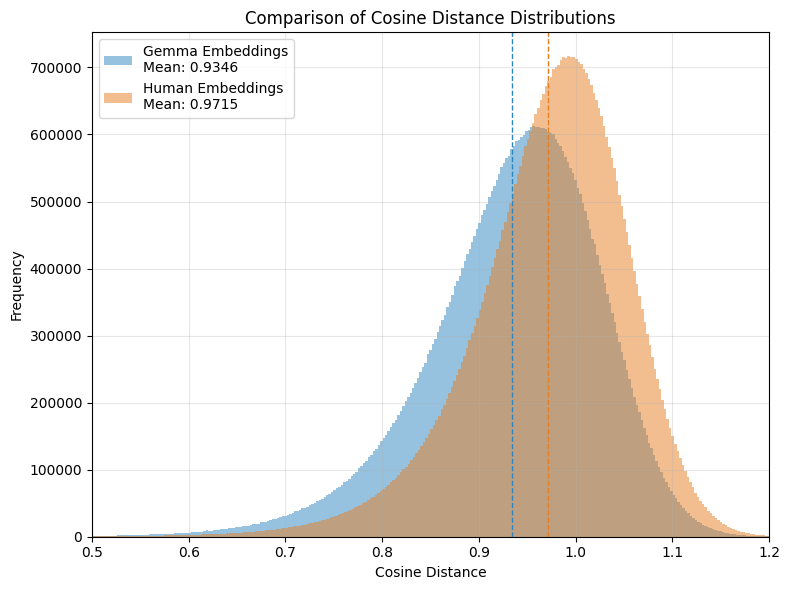

In [26]:
def plot_overlaid_cosine_distance_histograms(file_paths, labels, colors=['#A1C9F4', '#FFB4B4'], alpha=0.5):
    """
    Plot overlaid histograms of cosine distances from multiple numpy files.
    
    Args:
        file_paths: List of paths to the .npy files containing the cosine distance matrices
        labels: List of labels for each distribution
        colors: List of colors for each histogram
        alpha: Transparency level for the histograms
    """
    plt.figure(figsize=(8, 6))
    
    for file_path, label, color in zip(file_paths, labels, colors):
        # Load the cosine distance matrix
        cosine_distances = np.load(file_path)
        
        # Flatten the matrix to get all pairwise distances
        # Exclude the diagonal (self-comparisons) which are always 0
        mask = ~np.eye(cosine_distances.shape[0], dtype=bool)
        distances = cosine_distances[mask]
        
        # Calculate mean
        mean_distance = np.mean(distances)
        
        # Create the histogram
        plt.hist(distances, bins=500, alpha=alpha, color=color, label=f'{label}\nMean: {mean_distance:.4f}')
        
        # Add a vertical line for the mean
        plt.axvline(mean_distance, color=color, linestyle='dashed', linewidth=1)
    
    # Add labels and title
    plt.xlabel('Cosine Distance')
    plt.ylabel('Frequency')
    plt.title('Comparison of Cosine Distance Distributions')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0.5, 1.2)  
    plt.tight_layout()
    plt.show()

# Example usage:
file_paths = [
    "../../Data/analysis/semantic_diversity/Small/cosine_distances_dolly_train_2_Gemma_embeddings.npy",
    "../../Data/analysis/semantic_diversity/Human/cosine_distances_dolly_train_2_human_embeddings.npy"
    #"../../Data/analysis/semantic_diversity/Small/cosine_distances_dolly_train_4_Falcon3-10B-Instruct_embeddings.npy"
]
labels = ['Gemma Embeddings', 'Human Embeddings']
colors = ['#2E86C1', '#E67E22']  # Ocean blue and orange
plot_overlaid_cosine_distance_histograms(file_paths, labels, colors)

# Compare gemini with and without system prompt

Loading embeddings...
Calculating cosine distances...
Gemini Semantic Diversity: 0.934484 (SE: 0.000013)
Gemini with System Prompt Semantic Diversity: 0.937226 (SE: 0.000013)


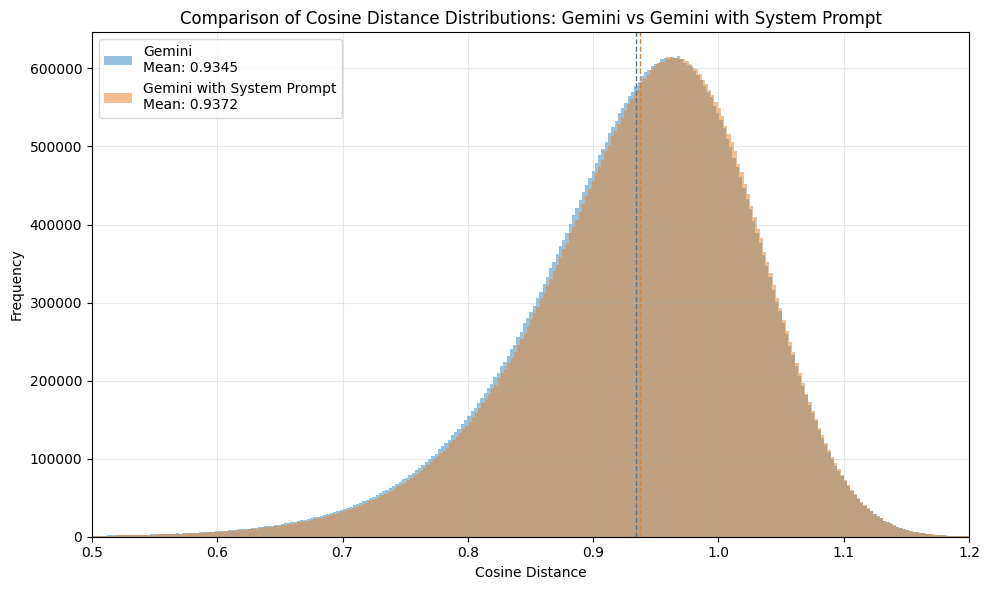

In [3]:
from sklearn.metrics.pairwise import cosine_distances

# Define paths
gemini_path = "../../Data/analysis/sentence_embeddings/Large/dolly_train_2_Gemini_embeddings.jsonl"
gemini_system_path = "../../Data/analysis/sentence_embeddings/Large/dolly_train_2_Gemini_with_system_prompt_embeddings.jsonl"

# Function to load embeddings from jsonl file
def load_embeddings_from_jsonl(file_path):
    embeddings = []
    with open(file_path, 'r') as f:
        for line in f:
            data = json.loads(line)
            embeddings.append(data['embedding'])
    return np.array(embeddings)

# Function to calculate and save cosine distance matrix
def calculate_cosine_distances(embeddings, output_path):
    # Create directory if it doesn't exist
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    # Calculate cosine distances
    distances = cosine_distances(embeddings)
    
    # Save the distance matrix
    np.save(output_path, distances)
    
    return distances

# Function to calculate semantic diversity
def calculate_semantic_diversity(distances):
    # Exclude the diagonal (self-comparisons)
    mask = ~np.eye(distances.shape[0], dtype=bool)
    pairwise_distances = distances[mask]
    
    # Calculate mean distance (semantic diversity)
    semantic_diversity = np.mean(pairwise_distances)
    
    # Calculate standard error
    standard_error = np.std(pairwise_distances) / np.sqrt(len(pairwise_distances))
    
    return semantic_diversity, standard_error

# Load embeddings
print("Loading embeddings...")
gemini_embeddings = load_embeddings_from_jsonl(gemini_path)
gemini_system_embeddings = load_embeddings_from_jsonl(gemini_system_path)

# Calculate and save cosine distances
print("Calculating cosine distances...")
gemini_output_path = "../../Data/analysis/semantic_diversity/Large/cosine_distances_dolly_train_2_Gemini_embeddings.npy"
gemini_system_output_path = "../../Data/analysis/semantic_diversity/Large/cosine_distances_dolly_train_2_Gemini_with_system_prompt_embeddings.npy"

gemini_distances = calculate_cosine_distances(gemini_embeddings, gemini_output_path)
gemini_system_distances = calculate_cosine_distances(gemini_system_embeddings, gemini_system_output_path)

# Calculate semantic diversity
gemini_diversity, gemini_se = calculate_semantic_diversity(gemini_distances)
gemini_system_diversity, gemini_system_se = calculate_semantic_diversity(gemini_system_distances)

print(f"Gemini Semantic Diversity: {gemini_diversity:.6f} (SE: {gemini_se:.6f})")
print(f"Gemini with System Prompt Semantic Diversity: {gemini_system_diversity:.6f} (SE: {gemini_system_se:.6f})")

# Plot histograms
plt.figure(figsize=(10, 6))

# Flatten the matrices to get all pairwise distances (excluding diagonals)
mask_gemini = ~np.eye(gemini_distances.shape[0], dtype=bool)
mask_gemini_system = ~np.eye(gemini_system_distances.shape[0], dtype=bool)

gemini_flat = gemini_distances[mask_gemini]
gemini_system_flat = gemini_system_distances[mask_gemini_system]

# Create histograms
plt.hist(gemini_flat, bins=500, alpha=0.5, color='#2E86C1', 
         label=f'Gemini\nMean: {gemini_diversity:.4f}')
plt.hist(gemini_system_flat, bins=500, alpha=0.5, color='#E67E22', 
         label=f'Gemini with System Prompt\nMean: {gemini_system_diversity:.4f}')

# Add vertical lines for means
plt.axvline(gemini_diversity, color='#2E86C1', linestyle='dashed', linewidth=1)
plt.axvline(gemini_system_diversity, color='#E67E22', linestyle='dashed', linewidth=1)

# Add labels and title
plt.xlabel('Cosine Distance')
plt.ylabel('Frequency')
plt.title('Comparison of Cosine Distance Distributions: Gemini vs Gemini with System Prompt')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0.5, 1.2)
plt.tight_layout()
plt.show()
